In [1]:
library(readr)
library(stringr)
library(dplyr)
set.seed(1234)

#### Send to channel code
library(parallel)
library(ggpubr)
library(qvalue)

suppressMessages(library(chromVAR))
suppressMessages(library(motifmatchr))
suppressMessages(library(SummarizedExperiment))

library(pheatmap)
library(RColorBrewer)
library(beeswarm)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: ggplot2



In [2]:
in_dir <- '/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/'

#Load in devscores, info, motif
motifdata <- read.table(file=paste0(in_dir,'motifdata.txt'), sep="\t")
info <- read.table(file=paste0(in_dir,'info_table.txt'))
TFClass_Lookup <- read_csv("/nfs/lab/welison/References/220907_WE_Chromvar_to_Gene_By_Subfam_Complete(JAPRAR2022_TFClass).csv")
TFClass_Full <- read_csv("/nfs/lab/welison/References/220907_WE_Chromvar_to_Gene_Jaspar2022.csv")
variability <- read.table(file=paste0(in_dir,'variability.txt'), sep="\t")

head(motifdata)
head(info)
dim(TFClass_Lookup)
head(TFClass_Lookup)

head(variability)
dim(variability)

Rows: 10368 Columns: 4
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (4): full_jaspar_motif, jaspar_motif, lowest_level_family, gene

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1669 Columns: 20
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (20): full_jaspar_motif, jaspar_motif, jaspar_name_1, jaspar_name_2, TFC...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


,V1,V2,V3
,<chr>,<chr>,<chr>
1,MA0030.1_FOXF2,FOXF2,Fork head/winged helix factors
2,MA0031.1_FOXD1,FOXD1,Fork head/winged helix factors
3,MA0051.1_IRF2,IRF2,Tryptophan cluster factors
4,MA0059.1_MAX::MYC,MAX::MYC,Basic helix-loop-helix factors (bHLH)
5,MA0066.1_PPARG,PPARG,Nuclear receptors with C4 zinc fingers
6,MA0069.1_PAX6,PAX6,Paired box factors


,def,cells,groups,cluster,samples,FRIP,TSS.enrichment,nCount_ATAC,nFeature_ATAC
,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<int>,<int>
MM_339_AAACGAATCCCGAAGC-1,MM_339,MM_339_AAACGAATCCCGAAGC-1,earlyT1D,Acinar_1_2_6,6247,0.5421319,4.928013,748,715
MM_339_AAACGAATCTATGAGC-1,MM_339,MM_339_AAACGAATCTATGAGC-1,earlyT1D,Acinar_1_2_6,6247,0.7366399,5.622038,830,802
MM_339_AAACTCGGTGTGCTTA-1,MM_339,MM_339_AAACTCGGTGTGCTTA-1,earlyT1D,Acinar_1_2_6,6247,0.6134342,4.720066,505,489
MM_339_AAAGATGTCGGATGTT-1,MM_339,MM_339_AAAGATGTCGGATGTT-1,earlyT1D,Acinar_1_2_6,6247,0.6927803,4.036170,746,726
MM_339_AAAGGATAGGAGTCTG-1,MM_339,MM_339_AAAGGATAGGAGTCTG-1,earlyT1D,Acinar_1_2_6,6247,0.7235805,5.164169,621,602
MM_339_AAAGGATAGTCGAGCA-1,MM_339,MM_339_AAAGGATAGTCGAGCA-1,earlyT1D,Acinar_1_2_6,6247,0.5906291,4.659066,834,797


[1] 10368     4

full_jaspar_motif,jaspar_motif,lowest_level_family,gene
<chr>,<chr>,<chr>,<chr>
MA0030.1_FOXF2,FOXF2,FOXF,FOXF2
MA0030.1_FOXF2,FOXF2,FOXF,FOXF1
MA0031.1_FOXD1,FOXD1,FOXD,FOXD1
MA0031.1_FOXD1,FOXD1,FOXD,FOXD2
MA0031.1_FOXD1,FOXD1,FOXD,FOXD3
MA0031.1_FOXD1,FOXD1,FOXD,FOXD4L1


,name,variability,bootstrap_lower_bound,bootstrap_upper_bound,p_value,p_value_adj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MA0030.1_FOXF2,FOXF2,1.203838,1.198981,1.208643,0.000000e+00,0.000000e+00
MA0031.1_FOXD1,FOXD1,1.258115,1.252999,1.263342,0.000000e+00,0.000000e+00
MA0051.1_IRF2,IRF2,1.113662,1.108953,1.118249,0.000000e+00,0.000000e+00
MA0059.1_MAX::MYC,MAX::MYC,1.035252,1.031647,1.038709,1.326763e-95,1.932884e-95
MA0066.1_PPARG,PPARG,1.018128,1.014559,1.021752,6.234495e-27,7.676638e-27
MA0069.1_PAX6,PAX6,1.054041,1.049918,1.058356,2.990752e-220,5.306667e-220


[1] 692   6

In [3]:
#Devscores are slow to load, so this is a faster but awkward workaround
dev_file <- paste0(in_dir,'devscores.txt')

devscores <- vroom::vroom(file=dev_file, skip=1, col_names=FALSE)
devscores <- tibble::column_to_rownames(devscores, var="X1")
colnames(devscores) <- str_split(readLines(file(dev_file),n=1), " ")[[1]]

head(devscores)

Rows: 692 Columns: 174599
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: " "
chr      (1): X1
dbl (174598): X2, X3, X4, X5, X6, X7, X8, X9, X10, X11, X12, X13, X14, X15, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


,MM_339_AAACGAATCCCGAAGC-1,MM_339_AAACGAATCTATGAGC-1,MM_339_AAACTCGGTGTGCTTA-1,MM_339_AAAGATGTCGGATGTT-1,MM_339_AAAGGATAGGAGTCTG-1,MM_339_AAAGGATAGTCGAGCA-1,MM_339_AAAGGGCCAGTCAGCC-1,MM_339_AAAGGGCTCGATATGC-1,MM_339_AAAGGGCTCGGTTAGT-1,MM_339_AAATGAGGTGCCAAGA-1,⋯,MM_391_GTGCCAGCAGGGTAAC-1,MM_460_AAATGCCGTGCATTGT-1,MM_460_GCACCTTCATGCGCTG-1,MM_460_GTAATCGCAAAGAAGG-1,MM_460_TAGTCCCAGAAAGCAG-1,MM_460_TTCATTGTCGCAAACT-1,MM_536_GGAGGATCATCCCTCA-1,MM_544_CTAGCGGGTTTAGACC-1,MM_546_GCACGGTCAGTCAGCC-1,MM_546_TTGCAGAGTTCTGAGT-1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MA0030.1_FOXF2,0.54520151,0.40990183,3.35607428,2.000801239,0.9658235,-0.459021816,0.44334913,-0.25558497,-1.6471011,0.8835954,⋯,-1.3485672,-1.24054617,0.6432168,0.53422671,-0.8512291,0.34641291,-1.3156336,-0.1606987,-0.4841276,-0.1220044
MA0031.1_FOXD1,-0.64639620,0.56733851,2.16471443,0.222432873,0.1040411,-1.840425687,1.07262678,-0.05391174,1.3205662,0.8736271,⋯,-2.0031346,-1.47942813,-0.2572786,-0.84672181,-1.4112522,-1.44849245,-1.0407649,-0.3555410,-2.0004751,-1.9848008
MA0051.1_IRF2,-0.04734576,0.21278816,-1.17043162,0.006864465,-0.6147434,0.779877039,-0.95418391,0.84427104,-0.1533793,-0.6127317,⋯,0.3081769,0.92292903,1.0573372,0.55484583,-0.8093365,1.63052376,0.6905937,-1.1745899,3.0360215,0.9012208
MA0059.1_MAX::MYC,-0.01129497,0.06407827,-0.60875582,-0.568995229,1.0334839,0.008193637,-1.30026440,-0.93085128,-2.0120367,-0.2730295,⋯,-1.1595347,0.42933240,2.3681214,-1.55277513,-1.3609323,-1.10154128,-1.9283999,-0.4375171,-0.9435472,-1.2343960
MA0066.1_PPARG,0.51365043,-0.50851101,-0.55188880,-0.488296947,-0.6396850,0.131552195,-0.30285472,1.31740292,1.8427194,0.4069058,⋯,1.3590695,0.03172931,0.1511277,0.35230581,-1.8023297,-0.83032002,0.4737512,-0.1385413,-0.9820997,-0.3458552
MA0069.1_PAX6,-2.20269142,-0.84260738,-0.01861448,0.711684614,-1.0814076,0.492742898,0.09633553,-0.41465127,-1.0573779,0.4792118,⋯,-0.5531416,1.12677198,-0.6887637,0.07516654,-1.1501492,0.08811665,-1.6427782,-0.6124164,-0.0492491,-2.0683459


In [4]:
# Originial deviaiton score matrix, may not be needed now that I am loading in variability directly
dev <- readRDS("/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240209_WE_ChromVAR_Object.RDS")
jaspar.motifs <- readRDS(file ='/nfs/lab/welison/multiome/chromvar/jaspar_2022_object.Rdata')

dev

class: chromVARDeviations 
dim: 692 174598 
metadata(0):
assays(2): deviations z
rownames(692): MA0030.1_FOXF2 MA0031.1_FOXD1 ... MA1633.2_BACH1
  MA0597.2_THAP1
rowData names(3): name fractionMatches fractionBackgroundOverlap
colnames(174598): MM_339_AAACGAATCCCGAAGC-1 MM_339_AAACGAATCTATGAGC-1
  ... MM_546_GCACGGTCAGTCAGCC-1 MM_546_TTGCAGAGTTCTGAGT-1
colData names(11): orig.ident nCount_ATAC ... frac_reads_in_peaks
  TSS.enrichment

# Filter by variability and # cells

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


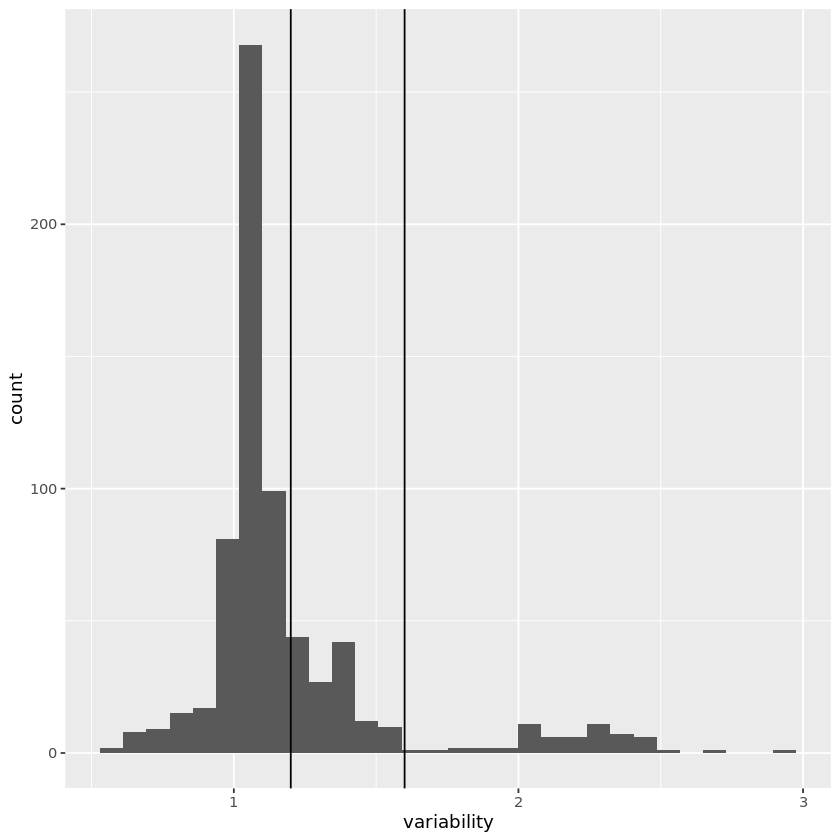

In [5]:
# Examine variability to pick a cutoff 
ggplot(variability, aes(x=variability)) +
geom_histogram() + geom_vline(xintercept = 1.2) + geom_vline(xintercept = 1.6)

In [6]:
# Check variablity filters, 1.2 seems fine

sum(variability$variability > 1.2)
length(variability$variability > 1.2)

sum(variability$p_value < 0.05)
sum(variability$p_value_adj < 0.05)

sum(variability$p_value_adj < 0.05 & variability$variability > 1.2)

[1] 178

[1] 692

[1] 589

[1] 589

[1] 178

In [7]:
# Subset deviation scores by variability
variable_to_keep <- rownames(filter(variability, variability > 1.2))

var_subset_devscores <- devscores[variable_to_keep,]
dim(var_subset_devscores)
head(var_subset_devscores)

[1]    178 174598

,MM_339_AAACGAATCCCGAAGC-1,MM_339_AAACGAATCTATGAGC-1,MM_339_AAACTCGGTGTGCTTA-1,MM_339_AAAGATGTCGGATGTT-1,MM_339_AAAGGATAGGAGTCTG-1,MM_339_AAAGGATAGTCGAGCA-1,MM_339_AAAGGGCCAGTCAGCC-1,MM_339_AAAGGGCTCGATATGC-1,MM_339_AAAGGGCTCGGTTAGT-1,MM_339_AAATGAGGTGCCAAGA-1,⋯,MM_391_GTGCCAGCAGGGTAAC-1,MM_460_AAATGCCGTGCATTGT-1,MM_460_GCACCTTCATGCGCTG-1,MM_460_GTAATCGCAAAGAAGG-1,MM_460_TAGTCCCAGAAAGCAG-1,MM_460_TTCATTGTCGCAAACT-1,MM_536_GGAGGATCATCCCTCA-1,MM_544_CTAGCGGGTTTAGACC-1,MM_546_GCACGGTCAGTCAGCC-1,MM_546_TTGCAGAGTTCTGAGT-1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MA0030.1_FOXF2,0.54520151,0.4099018,3.35607428,2.0008012,0.9658235,-0.45902182,0.4433491,-0.25558497,-1.6471011,0.88359545,⋯,-1.3485672,-1.2405462,0.6432168,0.5342267,-0.8512291,0.3464129,-1.315634,-0.1606987,-0.4841276,-0.1220044
MA0031.1_FOXD1,-0.64639620,0.5673385,2.16471443,0.2224329,0.1040411,-1.84042569,1.0726268,-0.05391174,1.3205662,0.87362710,⋯,-2.0031346,-1.4794281,-0.2572786,-0.8467218,-1.4112522,-1.4484925,-1.040765,-0.3555410,-2.0004751,-1.9848008
MA0077.1_SOX9,1.57784214,0.1978458,0.91235752,-1.8112762,-0.8501250,0.92581927,-1.3405739,-0.45413972,-0.3632695,0.91451602,⋯,2.6278018,4.2214255,1.8870657,3.2589645,2.3501462,4.1330383,2.156818,2.5092935,3.6772921,1.4851117
MA0091.1_TAL1::TCF3,0.48250578,-0.6380898,-0.09620231,1.5053086,0.5218929,0.40584009,-0.0670933,1.84315168,1.9085946,-0.09998049,⋯,0.8671377,0.6645666,1.3399024,-1.6532569,0.9847394,2.2636877,2.064788,3.1852680,-3.0865397,0.5696658
MA0101.1_REL,0.19432818,0.5506616,0.24155858,-0.8595632,-1.2824176,-0.03979702,-1.1506119,-1.78322823,-0.6403507,-0.46157423,⋯,1.8083243,1.8460529,0.4697389,4.8053257,2.9055109,3.6976130,3.515540,0.8014521,0.4913860,2.5028448
MA0107.1_RELA,0.08707044,2.4183183,0.54351026,-1.2948365,-2.3830308,1.05029909,0.7575426,-0.84864960,-0.7226448,-0.32522239,⋯,2.0373125,2.4531804,-1.1410048,5.0316008,1.8861456,2.7491922,3.038718,1.9337091,1.0002994,2.9023745


In [8]:
# Average by cell type
mat_type = sapply(unique(info$cluster), 
                function(i) rowMeans(var_subset_devscores[info$cells[info$cluster==i]], na.rm=TRUE))
head(mat_type)
dim(mat_type)

,Acinar_1_2_6,Acinar_5,Acinar_3,Acinar_4,Ductal,Activated_Stellate,Endothelial,Schwann,Alpha,Delta,Beta,Macrophage,Tcells,Mast,Quiescent_Stellate,LymphEndo,Bcells,MUC5b_Ductal
MA0030.1_FOXF2,0.18090890,0.6243826,0.4634029,0.6142244,0.12099052,-1.8360070,0.3409541,-1.0780409,1.721151,1.4962836,2.2284293,-2.0879606,-0.5356956,-1.0359302,-0.2407391,-0.4698827,-1.3795825,-0.8853587
MA0031.1_FOXD1,0.23707422,0.8396763,0.6493963,0.9172930,0.07491968,-1.8686919,-0.1560946,-1.3614480,1.788221,1.4330336,2.2436505,-2.3677991,-0.4267511,-1.3835224,-0.6055986,-1.4158371,-1.2840385,0.7585162
MA0077.1_SOX9,-0.03073656,-0.1524680,-0.1141139,-0.1846448,0.78191367,-1.5038020,6.4136280,-0.9238871,-1.078266,-0.6721459,-0.8027029,-0.8858366,-0.4507968,-0.1094579,-1.5404029,2.4894324,-0.6342041,-0.2823053
MA0091.1_TAL1::TCF3,0.02614097,0.1052473,-0.1178392,0.2336397,-1.51963639,1.7868692,-1.5463748,0.7902649,2.958717,3.1346986,4.1591968,-1.8548224,-1.5134396,-1.4595793,1.2330944,0.1658882,-0.5304605,-3.3672650
MA0101.1_REL,-0.28426829,-0.9780909,-0.3285831,-1.1364842,1.28078320,0.6430692,3.0007648,1.1608178,-1.594840,-1.5823822,-1.9592217,-0.2748151,-0.9485734,-0.3862153,1.3014592,1.4398414,-0.5657807,-1.1103161
MA0107.1_RELA,-0.28993379,-0.9967092,-0.3198781,-1.1455526,1.19847434,0.8140464,3.0869802,0.8948454,-1.745423,-1.7263983,-2.1493777,-0.1997450,-0.8636374,-0.6680041,1.3768382,1.4281679,-0.3776220,-0.7288309


[1] 178  18

In [9]:
# Some cell types don't have enough cells for this to be meaningful
table(info$cluster)


      Acinar_1_2_6           Acinar_3           Acinar_4           Acinar_5 
            111011              20368                436               1377 
Activated_Stellate              Alpha             Bcells               Beta 
              5398               2328                  8               1915 
             Delta             Ductal        Endothelial          LymphEndo 
               209              21794               1976                 58 
        Macrophage               Mast       MUC5b_Ductal Quiescent_Stellate 
              4748                 12                  2                873 
           Schwann             Tcells 
                16               2069 

In [10]:
#Remove cell types with less then 50 cells
mat_df_filt <- mat_type[,!(colnames(mat_type) %in% c('Schwann', 'MUC5b_Ductal', 'Bcells', 'Mast', 'LymphEndo'))]

dim(mat_df_filt)
head(mat_df_filt)

[1] 178  13

,Acinar_1_2_6,Acinar_5,Acinar_3,Acinar_4,Ductal,Activated_Stellate,Endothelial,Alpha,Delta,Beta,Macrophage,Tcells,Quiescent_Stellate
MA0030.1_FOXF2,0.18090890,0.6243826,0.4634029,0.6142244,0.12099052,-1.8360070,0.3409541,1.721151,1.4962836,2.2284293,-2.0879606,-0.5356956,-0.2407391
MA0031.1_FOXD1,0.23707422,0.8396763,0.6493963,0.9172930,0.07491968,-1.8686919,-0.1560946,1.788221,1.4330336,2.2436505,-2.3677991,-0.4267511,-0.6055986
MA0077.1_SOX9,-0.03073656,-0.1524680,-0.1141139,-0.1846448,0.78191367,-1.5038020,6.4136280,-1.078266,-0.6721459,-0.8027029,-0.8858366,-0.4507968,-1.5404029
MA0091.1_TAL1::TCF3,0.02614097,0.1052473,-0.1178392,0.2336397,-1.51963639,1.7868692,-1.5463748,2.958717,3.1346986,4.1591968,-1.8548224,-1.5134396,1.2330944
MA0101.1_REL,-0.28426829,-0.9780909,-0.3285831,-1.1364842,1.28078320,0.6430692,3.0007648,-1.594840,-1.5823822,-1.9592217,-0.2748151,-0.9485734,1.3014592
MA0107.1_RELA,-0.28993379,-0.9967092,-0.3198781,-1.1455526,1.19847434,0.8140464,3.0869802,-1.745423,-1.7263983,-2.1493777,-0.1997450,-0.8636374,1.3768382


In [11]:
# Drop esspecially rare cell types
celltypes <- unique(info$cluster)
celltypes

celltypes_sub <- celltypes[!celltypes %in% c("Schwann", "MUC5b_Ductal", "Bcells", "Mast", "LymphEndo")]
celltypes_sub

[1] "Acinar_1_2_6"       "Acinar_5"           "Acinar_3"          
 [4] "Acinar_4"           "Ductal"             "Activated_Stellate"
 [7] "Endothelial"        "Schwann"            "Alpha"             
[10] "Delta"              "Beta"               "Macrophage"        
[13] "Tcells"             "Mast"               "Quiescent_Stellate"
[16] "LymphEndo"          "Bcells"             "MUC5b_Ductal"

[1] "Acinar_1_2_6"       "Acinar_5"           "Acinar_3"          
 [4] "Acinar_4"           "Ductal"             "Activated_Stellate"
 [7] "Endothelial"        "Alpha"              "Delta"             
[10] "Beta"               "Macrophage"         "Tcells"            
[13] "Quiescent_Stellate"

In [12]:
prcomp

function (x, ...) 
UseMethod("prcomp")
<bytecode: 0x55f9c1ffb568>
<environment: namespace:stats>

# Plots

In [13]:
# Get Families
TFClass_Fams <- select(TFClass_Full, -contains('_2'), -TFClass_subfamily_1, -TFClass_family_1, -TFClass_class_1,
       -TFClass_superclass_1, -TFClass_num_1, -RNA_name_1, -jaspar_motif, -jaspar_name_1, -TFClass_name_1)
TFClass_Fams <- TFClass_Fams[!duplicated(TFClass_Fams$full_jaspar_motif),]


dim(TFClass_Fams)
head(TFClass_Fams)

[1] 824   2

full_jaspar_motif,lowest_level_fam_1
<chr>,<chr>
MA0030.1_FOXF2,FOXF
MA0031.1_FOXD1,FOXD
MA0051.1_IRF2,IRF
MA0057.1_MZF1(var.2),More than 3 adjacent zinc fingers
MA0059.1_MAX::MYC,MYC
MA0066.1_PPARG,PPAR(NR1C)


In [14]:
# Matrix sorted by family
mat_df_fam <- tibble::rownames_to_column(as.data.frame(mat_df_filt), var='full_jaspar_motif')

#mat_df_fam

mat_df_fam <- left_join(mat_df_fam, TFClass_Fams)
mat_df_fam <- select(mat_df_fam, -full_jaspar_motif)
mat_df_fam <- arrange(mat_df_fam, lowest_level_fam_1)

mat_df_fam_labels<- mat_df_fam$lowest_level_fam_1
mat_df_fam_unique_labels <- unique(mat_df_fam$lowest_level_fam_1)
mat_df_fam <- select(mat_df_fam, -lowest_level_fam_1)
mat_df_fam <- as.matrix(mat_df_fam)
rownames(mat_df_fam) <- mat_df_fam_labels

mat_df_fam
mat_df_fam_unique_labels

Joining with `by = join_by(full_jaspar_motif)`


,Acinar_1_2_6,Acinar_5,Acinar_3,Acinar_4,Ductal,Activated_Stellate,Endothelial,Alpha,Delta,Beta,Macrophage,Tcells,Quiescent_Stellate
ASC,0.5063932,1.7241839,0.74126510,1.9417435,-0.75543480,-0.8974120,-2.0854352,1.0261550,1.1536712,1.7466773,-1.7879657,-0.95588625,-1.00133807
ASC,1.1138279,3.7929850,2.02171025,4.2840828,0.40573651,-6.2877137,-4.1551807,2.0108675,1.9889872,2.7622495,-3.6288536,-0.38278076,-6.10274717
ATF3-like,-0.5579453,-1.6105809,0.20428007,-1.8451441,-0.49274773,5.1745296,0.7363628,-3.2714493,-3.1309196,-1.5902733,0.8236194,-1.03988435,-0.37626076
ATF4-related,-0.2999093,-0.9203632,-0.29894439,-1.1471146,-0.56900614,3.6937994,-1.6538034,-1.0806622,-0.6240648,-0.9363393,1.5223846,-1.29611634,0.25125699
B-ATF-related,-0.6926245,-1.9783235,0.07512640,-2.2493967,-1.14772297,6.9693485,1.0636867,-3.8781090,-3.8012240,-2.2316217,1.6942730,-1.32612814,0.02448219
B-ATF-related,-0.6997713,-2.0010695,0.04457639,-2.2648294,-1.18046583,6.9344563,1.0989925,-3.8257872,-3.6891591,-2.1396707,1.7289186,-1.21110218,0.02770979
B-ATF-related,-0.6726500,-1.9255430,0.05461533,-2.2001409,-1.09957041,6.5485315,0.9631296,-3.6705399,-3.4982885,-2.0643473,1.6278803,-0.98735727,-0.06870428
Basonuclin,-0.6665846,-1.8689084,0.20448606,-2.1087397,-1.09919871,6.9938204,1.1706813,-4.1290645,-4.1266550,-2.4048814,1.6133907,-1.49826816,-0.27397447
CEBP,-0.3594729,-1.1659217,-0.44366437,-1.3300457,-0.26578464,3.9957711,-1.4235008,-1.9241137,-0.9271389,-1.7597061,2.4159902,-1.57075444,-0.33413158
CEBP,-0.3616381,-1.1084824,-0.41850886,-1.4105306,-0.70349294,4.5430509,-2.0062258,-1.6538695,-0.9585396,-1.4691001,2.1535366,-1.47010686,-0.15743593


[1] "ASC"                                         
 [2] "ATF3-like"                                   
 [3] "ATF4-related"                                
 [4] "B-ATF-related"                               
 [5] "Basonuclin"                                  
 [6] "CEBP"                                        
 [7] "COUP(NR2F)"                                  
 [8] "CTCF-like"                                   
 [9] "CUX"                                         
[10] "E2A-like"                                    
[11] "EBF-related"                                 
[12] "EHF-like"                                    
[13] "ELF1-like"                                   
[14] "ELK-like"                                    
[15] "ER-like(NR3A)"                               
[16] "ETS-like"                                    
[17] "ETV6-like"                                   
[18] "FOXA"                                        
[19] "FOXB"                                        
[20] "FOXC"                                        
[21] "FOXD"                                        
[22] "FOXF"                                        
[23] "FOXI"                                        
[24] "FOXJ"                                        
[25] "FOXK"                                        
[26] "FOXL"                                        
[27] "FOXN"                                        
[28] "FOXO"                                        
[29] "FOXP"                                        
[30] "Factors with multiple dispersed zinc fingers"
[31] "Fos"                                         
[32] "GATA double"                                 
[33] "GATA single"                                 
[34] "GR-like(NR3C)"                               
[35] "GRH-like"                                    
[36] "Group B"                                     
[37] "Group C"                                     
[38] "Group D"                                     
[39] "Group E"                                     
[40] "Group G"                                     
[41] "HIC"                                         
[42] "HNF1-like"                                   
[43] "HOX3"                                        
[44] "HOX4"                                        
[45] "IRF"                                         
[46] "Ikaros"                                      
[47] "Jun"                                         
[48] "Large MAF"                                   
[49] "MEIS"                                        
[50] "MESP"                                        
[51] "Myogenic TFs"                                
[52] "NF-1"                                        
[53] "NFE2"                                        
[54] "NFkappaB p65-like"                           
[55] "Neurogenin-ATO"                              
[56] "ONECUT"                                      
[57] "PBX"                                         
[58] "POU4"                                        
[59] "RFX"                                         
[60] "Runt-related"                                
[61] "SPI-like"                                    
[62] "STAT"                                        
[63] "Small MAF"                                   
[64] "Snail-like"                                  
[65] "TAL-HEN"                                     
[66] "TBX2-related"                                
[67] "TBX6-related"                                
[68] "TEF1-related"                                
[69] "TWIST"                                       
[70] "ZBTB7"                                       
[71] "ZEB"                                         
[72] "ZNF238-like"                                 
[73] NA

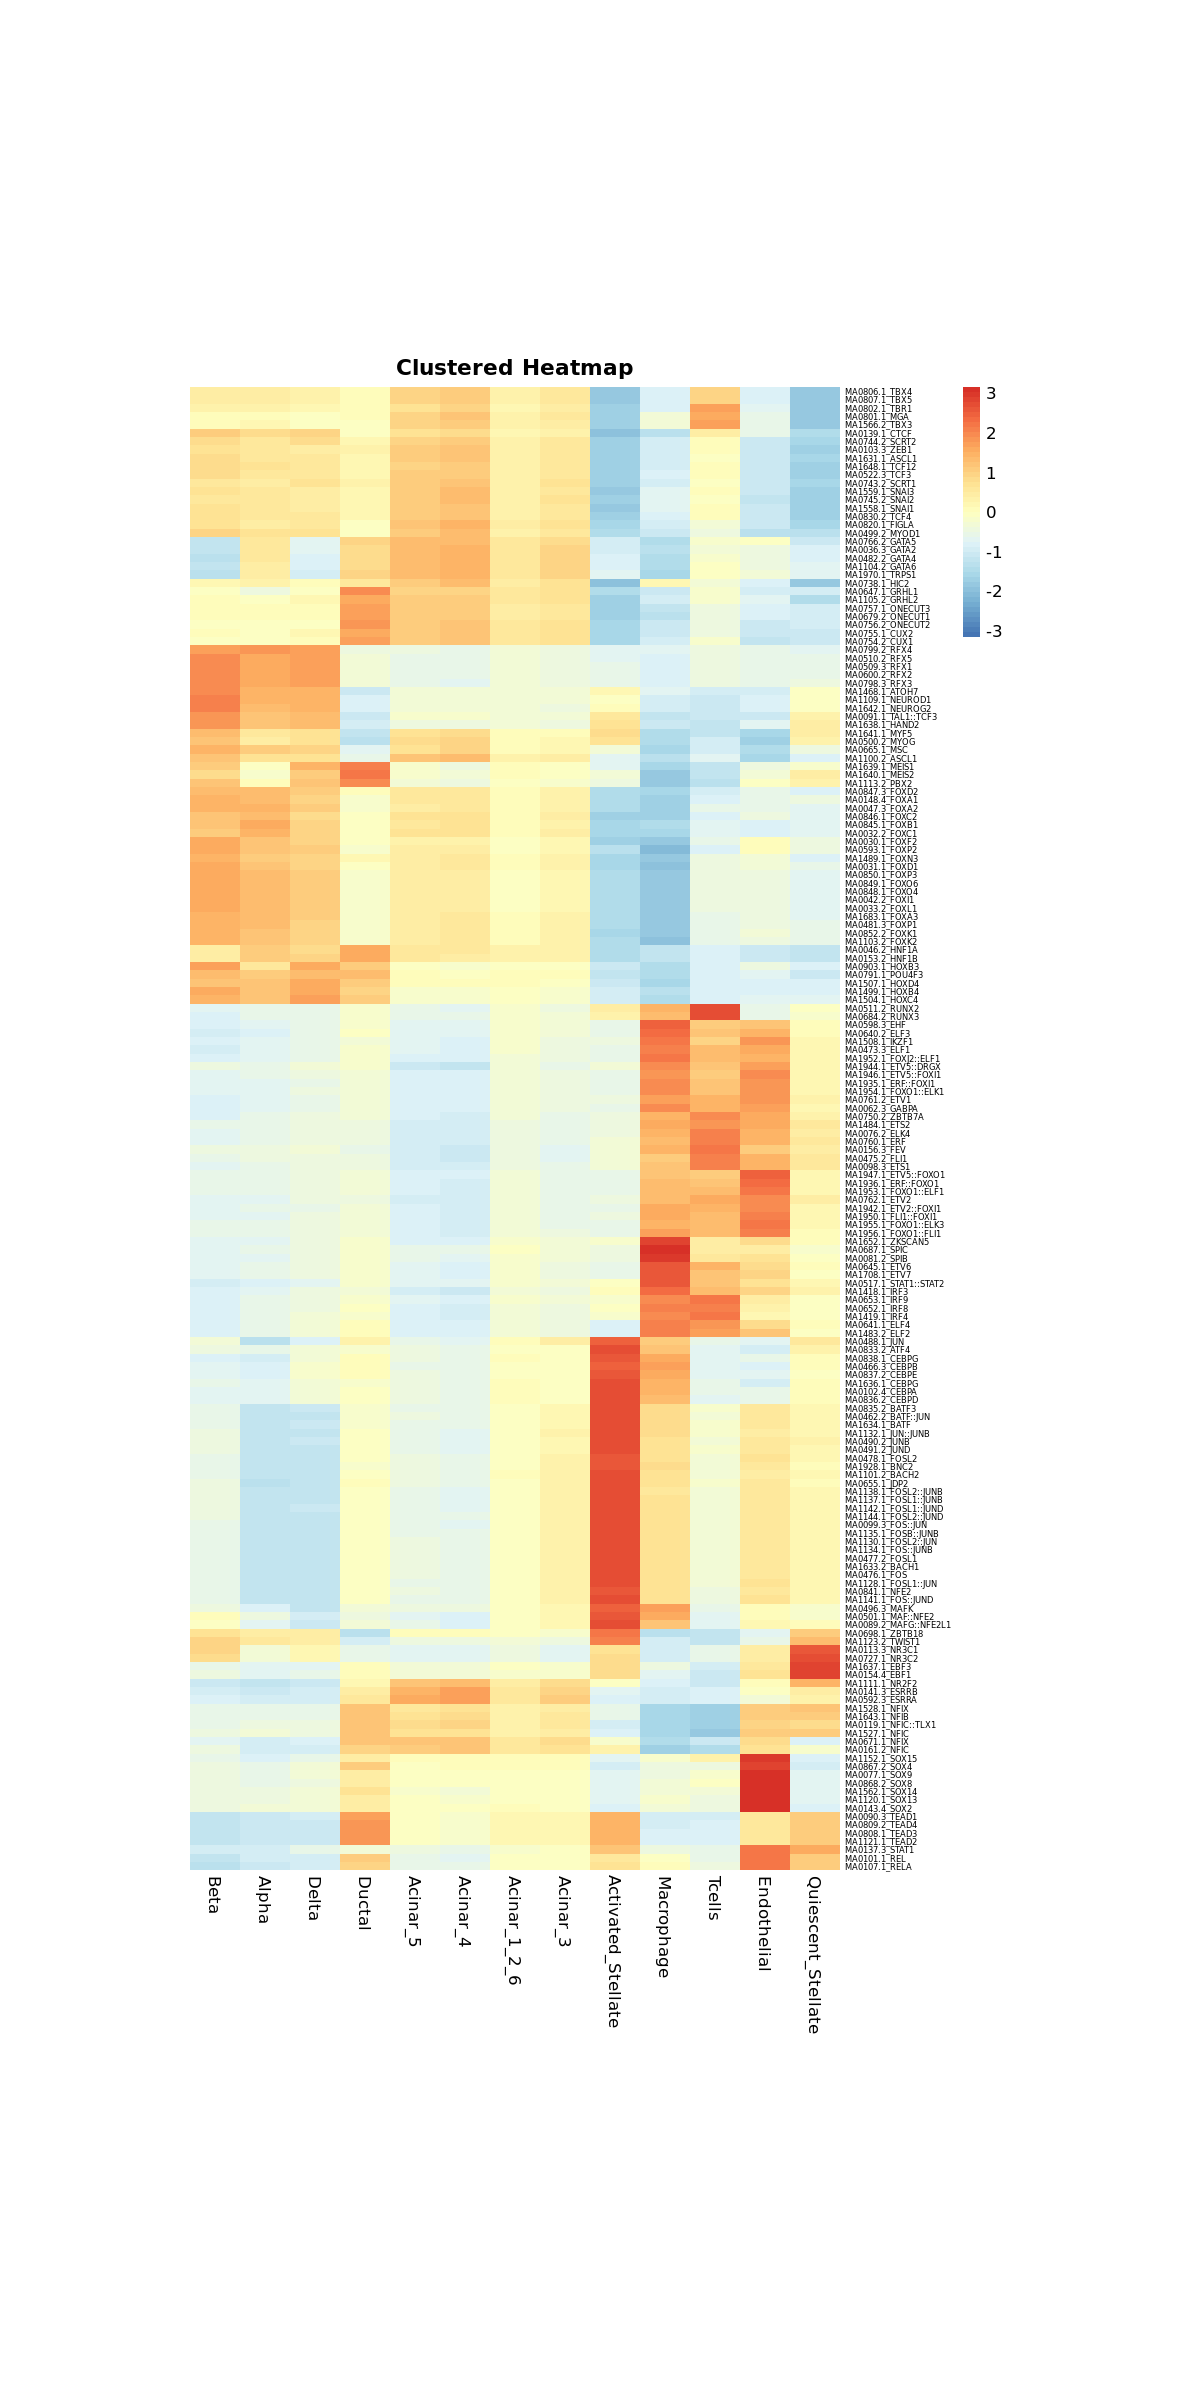

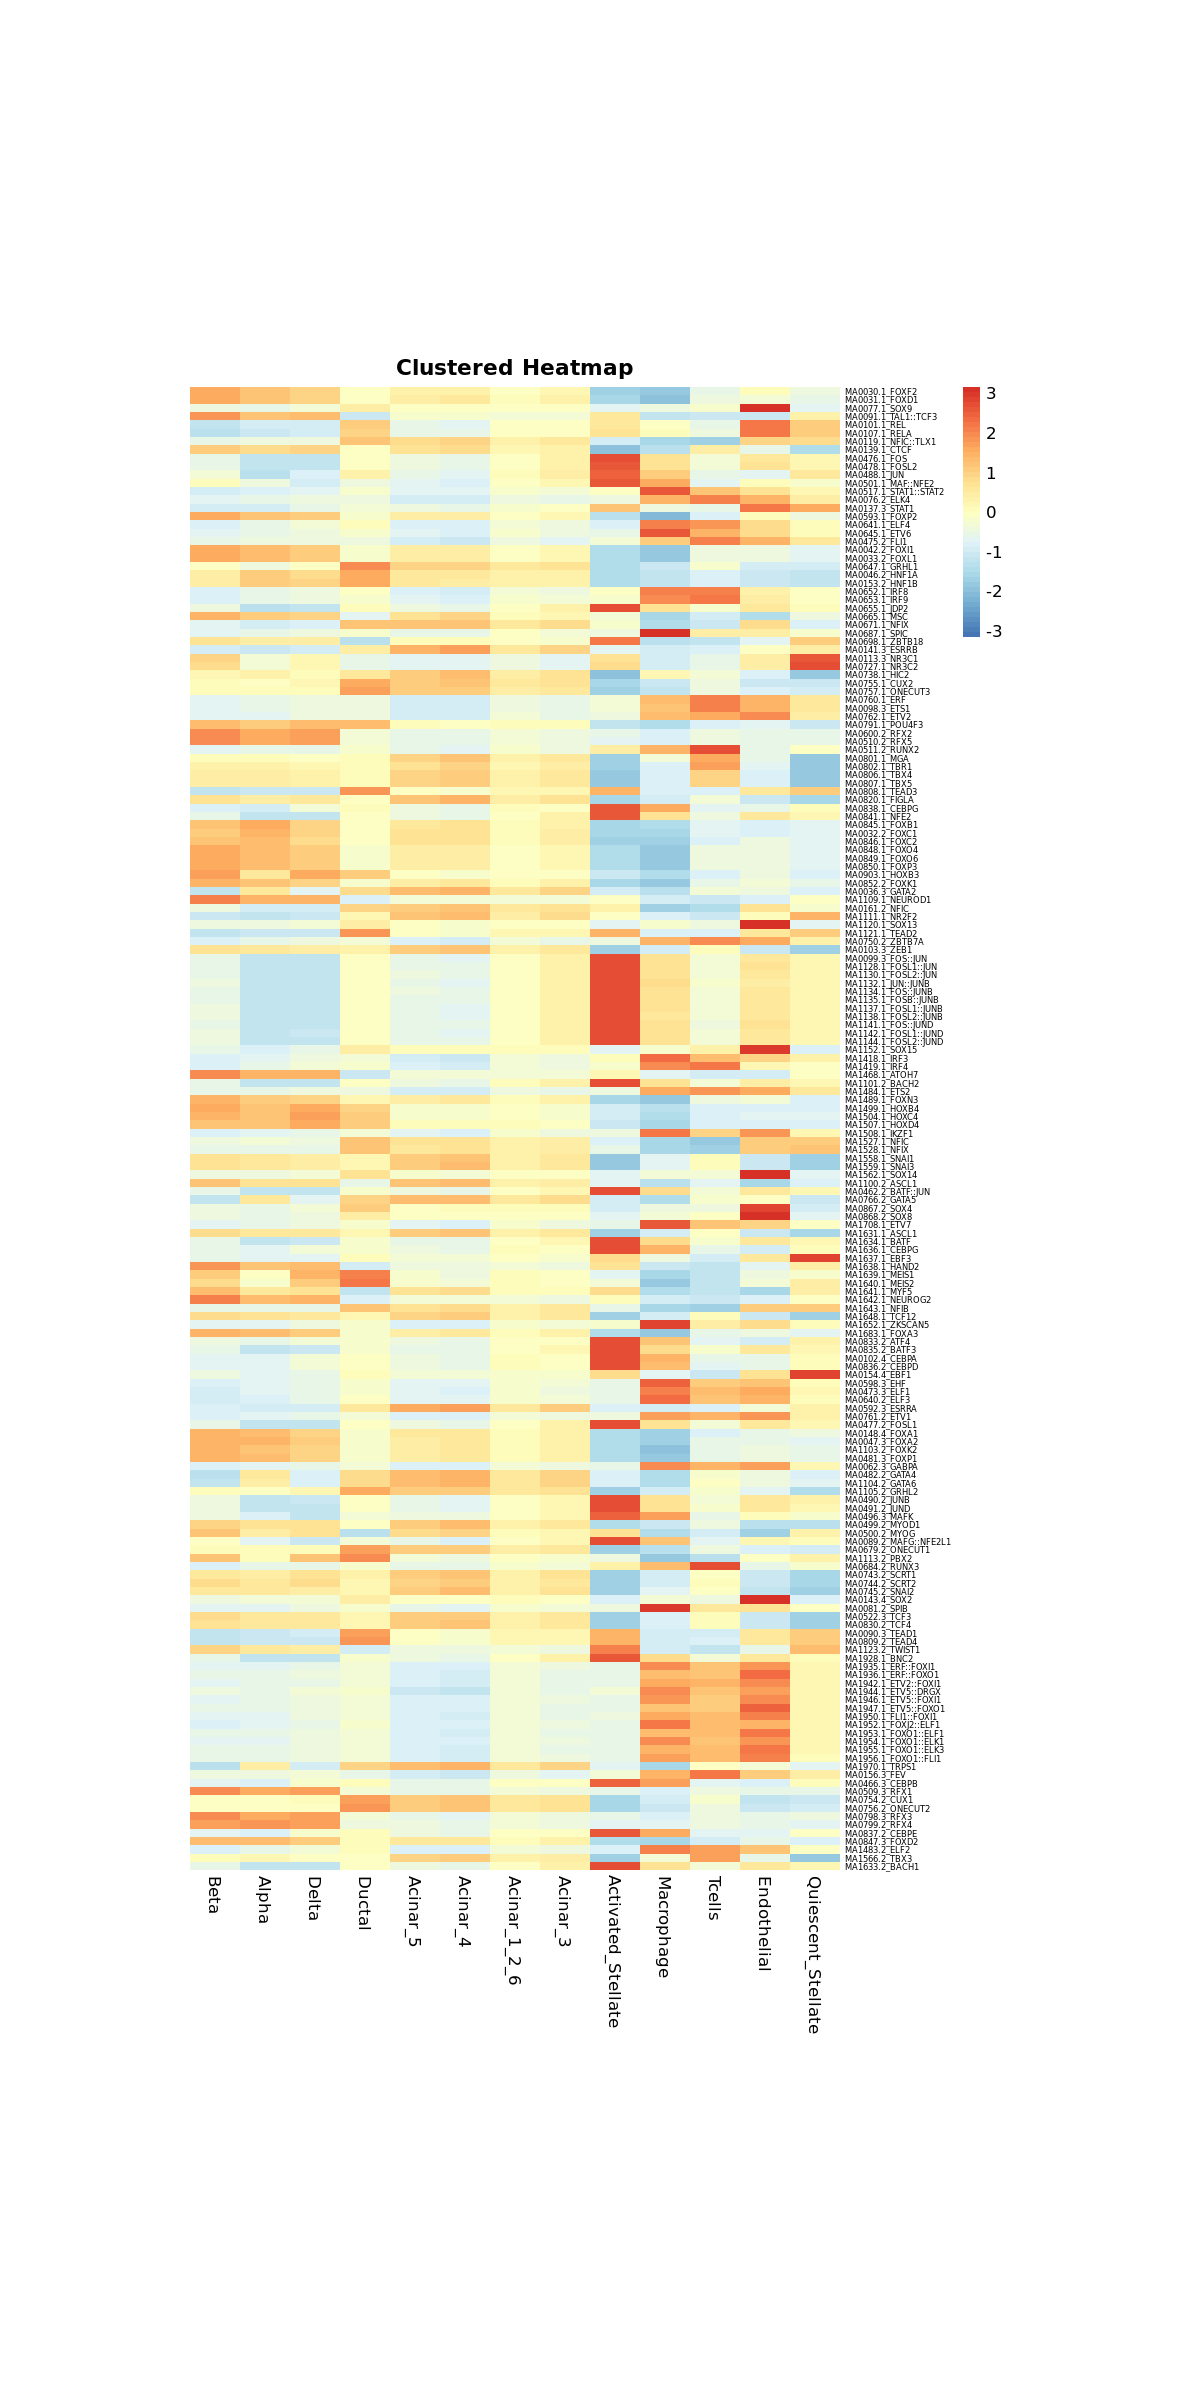

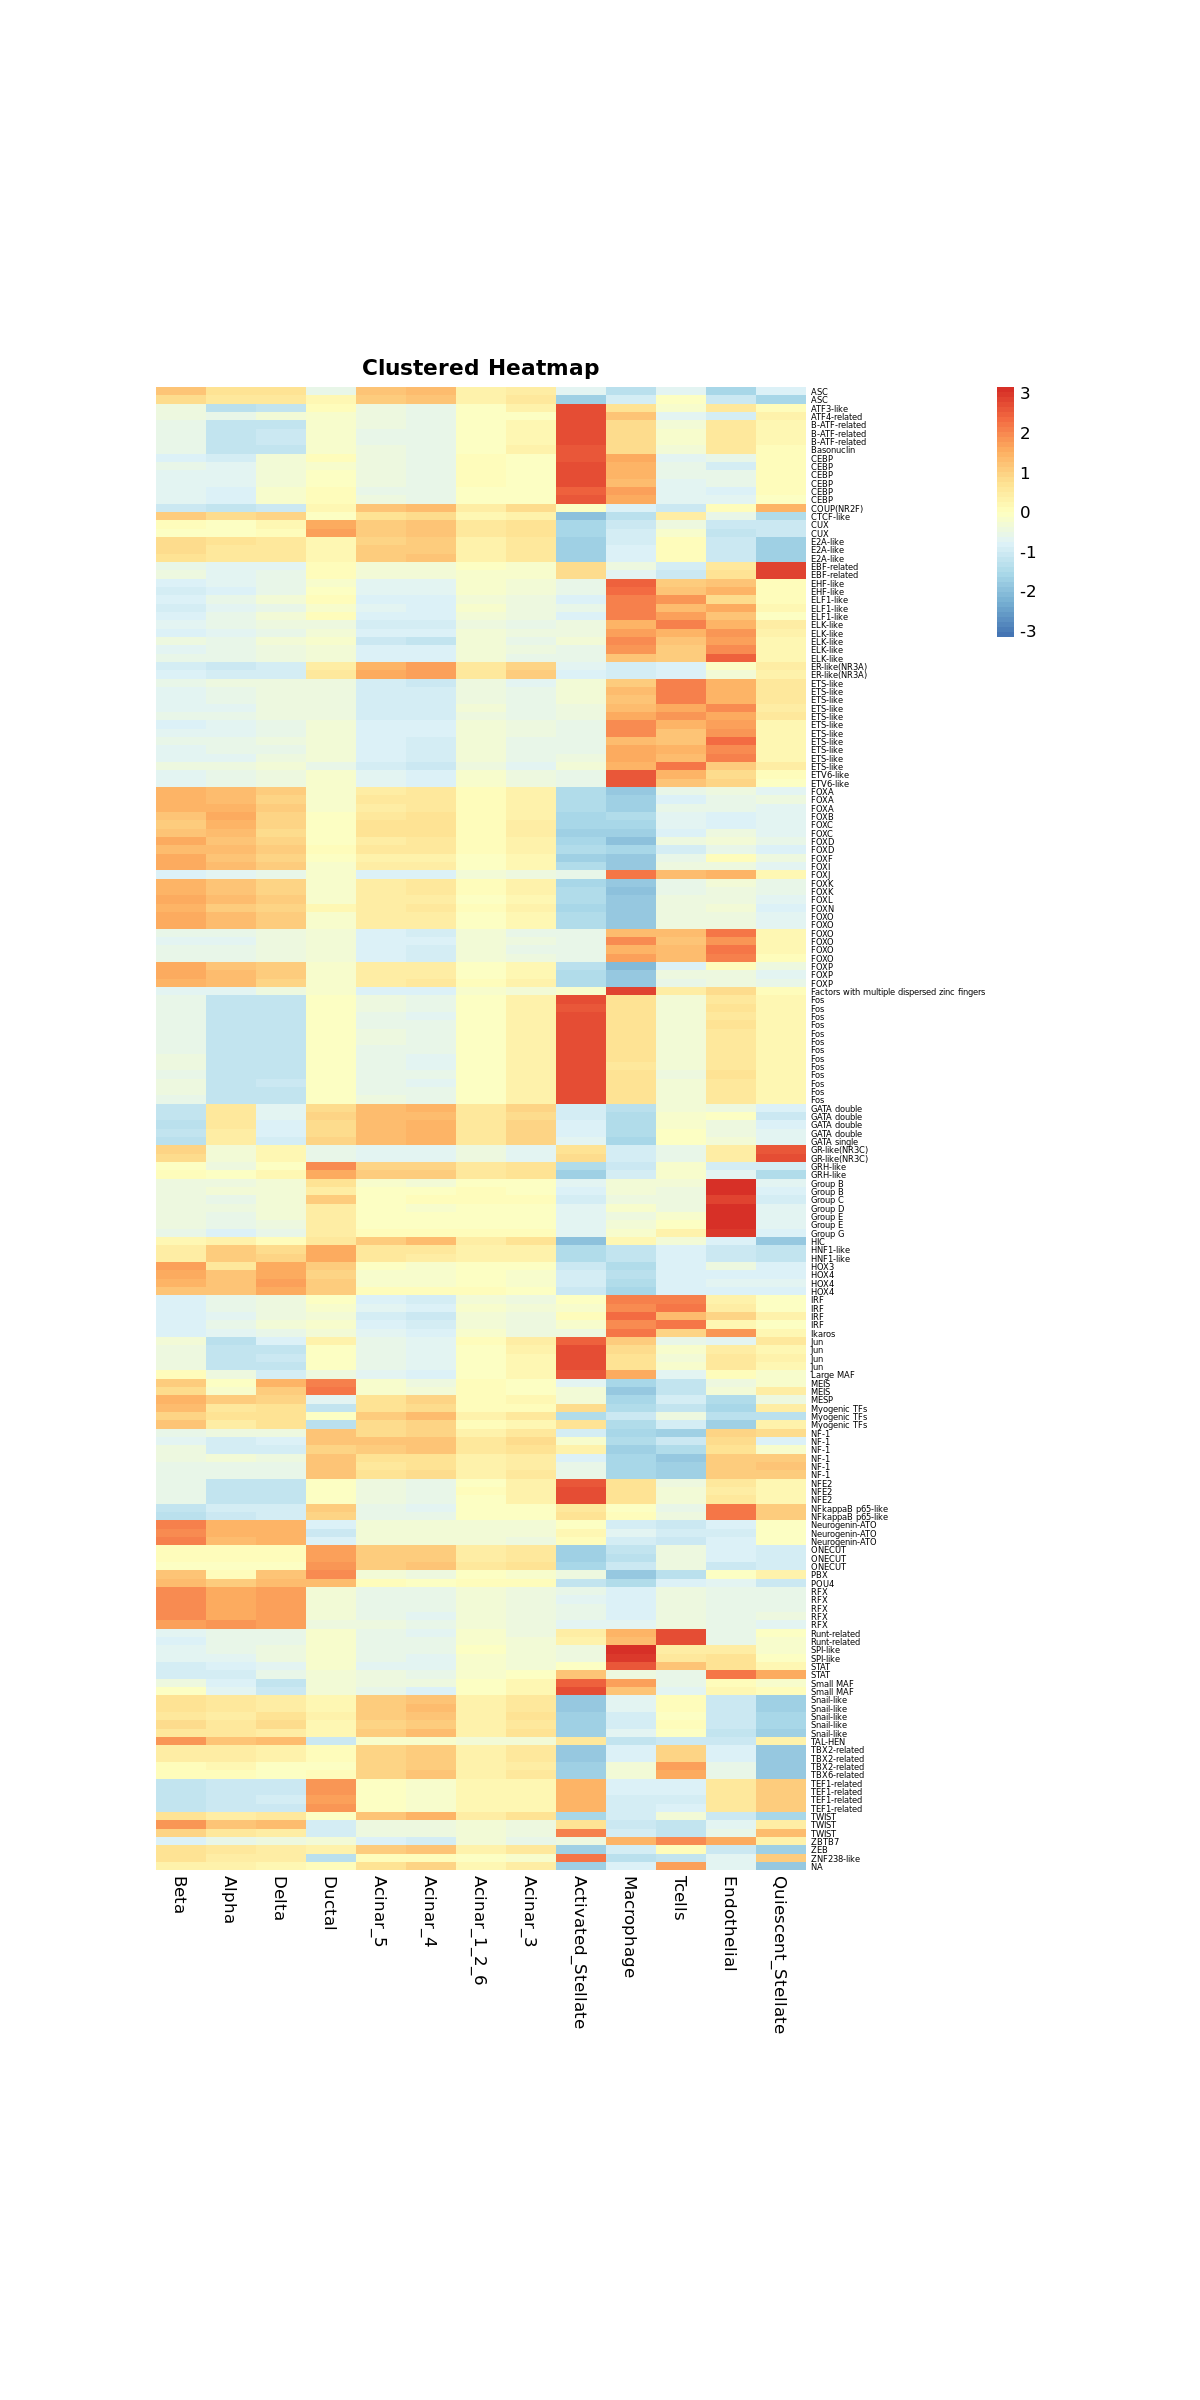

In [15]:
# Plot heatmaps
mypal = rev(colorRampPalette( brewer.pal(9, "RdYlBu"))(50))

#Sorted by dendorgram
options(repr.plot.width=10, repr.plot.height=20)
p1 <- pheatmap(mat_df_filt, scale = "row",
             fontsize_row = 5,
             border_color = NA,
             cellwidth = 30,cellheight = 5,
             #file = clustered_file,
             col =mypal, cluster_rows = T, cluster_cols = T,
             show_rownames = TRUE,
             treeheight_row=0, treeheight_col=0,
             main = paste0("Clustered Heatmap"))

#Not sorted
options(repr.plot.width=10, repr.plot.height=20)
p2 <- pheatmap(mat_df_filt, scale = "row",
             fontsize_row = 5,
             border_color = NA,
             cellwidth = 30,cellheight = 5,
             #file = clustered_file,
             col =mypal, cluster_rows = F, cluster_cols = T,
             show_rownames = TRUE,
             treeheight_row=0, treeheight_col=0,
             main = paste0("Clustered Heatmap"))

#Sorted by Family
options(repr.plot.width=10, repr.plot.height=20)
p2 <- pheatmap(mat_df_fam, scale = "row",
             fontsize_row = 5,
             border_color = NA,
             cellwidth = 30,cellheight = 5,
             #file = clustered_file,
             col =mypal, cluster_rows = F, cluster_cols = T,
             show_rownames = TRUE,
             treeheight_row=0, treeheight_col=0,
             main = paste0("Clustered Heatmap"))

In [16]:
# Save heatmaps
mypal = rev(colorRampPalette( brewer.pal(9, "RdYlBu"))(50))

#Sorted by dendorgram
options(repr.plot.width=10, repr.plot.height=20)
p1 <- pheatmap(mat_df_filt, scale = "row",
             fontsize_row = 5,
             border_color = NA,
             cellwidth = 30,cellheight = 5,
             file = "/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_ChromVAR_Across_CellTyes_Heatmap_Sorted.pdf",
             col =mypal, cluster_rows = T, cluster_cols = T,
             show_rownames = TRUE,
             treeheight_row=0, treeheight_col=0,
             main = paste0("Clustered Heatmap"))

#Not sorted
options(repr.plot.width=10, repr.plot.height=20)
p2 <- pheatmap(mat_df_filt, scale = "row",
             fontsize_row = 5,
             border_color = NA,
             cellwidth = 30,cellheight = 5,
             file = "/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_ChromVAR_Across_CellTyes_Heatmap.pdf",
             col =mypal, cluster_rows = F, cluster_cols = T,
             show_rownames = TRUE,
             treeheight_row=0, treeheight_col=0,
             main = paste0("Clustered Heatmap"))

#Sorted by Family
options(repr.plot.width=10, repr.plot.height=20)
p2 <- pheatmap(mat_df_fam, scale = "row",
             fontsize_row = 5,
             border_color = NA,
             cellwidth = 30,cellheight = 5,
             file = "/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_ChromVAR_Across_CellTyes_Heatmap_Sorted_by_Fam.pdf",
             col =mypal, cluster_rows = F, cluster_cols = T,
             show_rownames = TRUE,
             treeheight_row=0, treeheight_col=0,
             main = paste0("Clustered Heatmap"))